## 09 Xenium BANKSY Pseudotime Integration

**What this notebook does:** Integrates BANKSY spatial domain labels with pseudotime trajectory from the Xenium pancreatic dataset. Analyzes how BANKSY spatial neighborhoods relate to ductal progression.

**Data files needed:**
- `data/xenium_pancreas_10x/banksy/` (BANKSY results)
- `data/xenium_pancreas_10x/pseudotime/` (from notebook 07_xenium_03)
- BANKSY conda environment: `/Users/shihongwu/anaconda3/envs/pybanksy/`

**How to run:** Ensure both `spatioev_env` and `pybanksy` environments are available. Run 07_xenium_03 first.

In [ ]:
# DATA AVAILABILITY CHECK
import os
# BANKSY integration requires pseudotime and BANKSY results
_root = Path("/Users/shihongwu/SpatioEv")
_banksy_dir = _root / "data" / "xenium_pancreas_10x" / "banksy"
_required_files = [
    _banksy_dir,
    Path("/Users/shihongwu/anaconda3/envs/pybanksy/bin/python"),
]
_missing = [f for f in _required_files if not os.path.exists(f)]
if _missing:
    print(f'Missing required data files: {_missing}')
    print('   This notebook requires real experimental data to run.')
    print('   The code is shown for reference.')
else:
    print('All required data files found. Notebook is ready to run.')


# Xenium BANKSY domains on the SpatioEv pseudotime trajectory

This notebook runs **proper pyBANKSY** independently in the existing `/Users/shihongwu/anaconda3/envs/pybanksy` environment, then integrates BANKSY domains back onto the SpatioEv epithelial niche pseudotime table.

This version follows the logic of the reference notebook:

- concatenate multiple Xenium samples using common genes
- stagger sample coordinates so samples do not overlap spatially
- construct BANKSY matrices on the combined object
- Harmony-correct BANKSY PCs by sample
- run Leiden clustering on Harmony-corrected BANKSY PCs
- export per-sample BANKSY labels and summarize them by epithelial niche and niche surround

In [1]:
from pathlib import Path
import os
import subprocess

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

ROOT = Path("/Users/shihongwu/SpatioEv")
DATA_DIR = ROOT / "data" / "xenium_pancreas_10x"
BANKSY_DIR = DATA_DIR / "banksy"
FIG_DIR = ROOT / "notebooks" / "results" / "xenium_banksy_pseudotime"

BANKSY_PYTHON = Path("/Users/shihongwu/anaconda3/envs/pybanksy/bin/python")
SPATIOEV_PYTHON = Path("/Users/shihongwu/anaconda3/envs/spatioev_env/bin/python")

SAMPLE_IDS = [
    "pdac_pancreas_v1",
    "pdac_io_v1",
    "pdac_addon_v1",
    "normal_nondiseased_v1",
]

BANKSY_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

RUN_BANKSY = True
RUN_BANKSY_INTEGRATION = True

BANKSY_MAX_CELLS_PER_SAMPLE = 0  # 0 = all cells; set e.g. 50000 for a quick exploratory run.
BANKSY_NUM_NEIGHBOURS = 20
BANKSY_LAMBDAS = ["0.8"]
BANKSY_RESOLUTIONS = ["0.5"]
BANKSY_PCA_DIMS = ["20"]
BANKSY_PRIMARY_RUN_KEY = None

plt.rcParams.update({"font.size": 8})
sns.set_style("white")

print("BANKSY python:", BANKSY_PYTHON)
print("BANKSY python exists:", BANKSY_PYTHON.exists())

BANKSY python: /Users/shihongwu/anaconda3/envs/pybanksy/bin/python
BANKSY python exists: True


## 1. Run multi-sample BANKSY + Harmony

In [2]:
banksy_cmd = [
    str(BANKSY_PYTHON),
    str(ROOT / "scripts" / "run_xenium_banksy_harmony_multisample.py"),
    "--sample-id", "all",
    "--output-dir", str(BANKSY_DIR),
    "--num-neighbours", str(BANKSY_NUM_NEIGHBOURS),
    "--lambda-list", *BANKSY_LAMBDAS,
    "--resolutions", *BANKSY_RESOLUTIONS,
    "--pca-dims", *BANKSY_PCA_DIMS,
    "--max-cells-per-sample", str(BANKSY_MAX_CELLS_PER_SAMPLE),
]

banksy_env = os.environ.copy()
banksy_env.setdefault("NUMBA_CACHE_DIR", "/private/tmp/numba_cache")
banksy_env.setdefault("MPLCONFIGDIR", "/private/tmp/mplconfig")

if RUN_BANKSY:
    subprocess.run(banksy_cmd, cwd=ROOT, env=banksy_env, check=True)
else:
    print("Set RUN_BANKSY=True to run multi-sample pyBANKSY + Harmony.")
    print("Command:")
    print(" ".join(banksy_cmd))

for sample_id in SAMPLE_IDS:
    path = BANKSY_DIR / sample_id / f"{sample_id}_banksy_cell_domains.csv.gz"
    print(sample_id, "BANKSY domains exist:", path.exists(), path)

/Users/shihongwu/anaconda3/envs/pybanksy/lib/python3.10/site-packages/banksy/cluster_methods.py:24: UserWarning: 
No rpy2 installed. BANKSY will run, but mclust will not work.
Note: you can still use the default leiden option for clustering.
Install rpy2 and R in your conda environment if you want to use mclust for clustering.

  warnings.warn(warn_str)


Loading pdac_pancreas_v1: data/xenium_pancreas_10x/niche_features/pdac_pancreas_v1_with_niches.h5ad
Loading pdac_io_v1: data/xenium_pancreas_10x/niche_features/pdac_io_v1_with_niches.h5ad
Loading pdac_addon_v1: data/xenium_pancreas_10x/niche_features/pdac_addon_v1_with_niches.h5ad
Loading normal_nondiseased_v1: data/xenium_pancreas_10x/niche_features/normal_nondiseased_v1_with_niches.h5ad


/Users/shihongwu/anaconda3/envs/pybanksy/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Combined BANKSY input: 660,561 cells x 98 genes

Median distance to closest cell = 7.193239434242079

---- Ran median_dist_to_nearest_neighbour in 0.98 s ----

---- Ran generate_spatial_distance_graph in 2.95 s ----

---- Ran row_normalize in 0.66 s ----

---- Ran generate_spatial_weights_fixed_nbrs in 7.96 s ----

---- Ran generate_spatial_distance_graph in 4.88 s ----

---- Ran theta_from_spatial_graph in 2.40 s ----

---- Ran row_normalize in 0.68 s ----

---- Ran generate_spatial_weights_fixed_nbrs in 12.88 s ----

Runtime May-10-2026-21-03

98 genes to be analysed:
Gene List:
Index(['ACE2', 'ACTA2', 'ADAM28', 'AIF1', 'ANPEP', 'BANK1', 'CCL19', 'CCL5',
       'CCR2', 'CCR7', 'CD14', 'CD163', 'CD19', 'CD1A', 'CD1C', 'CD2', 'CD247',
       'CD27', 'CD274', 'CD28', 'CD3D', 'CD3E', 'CD4', 'CD68', 'CD79A', 'CD83',
       'CD86', 'CD8A', 'CDK1', 'CENPF', 'CLEC10A', 'CPA3', 'CTLA4', 'CXCL10',
       'CXCL2', 'CXCL6', 'CXCL9', 'CXCR4', 'DERL3', 'DMBT1', 'DUSP2', 'EGFR',
       'EPCAM', 'ER

/Users/shihongwu/anaconda3/envs/pybanksy/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Shape of BANKSY matrix: (660561, 294)
Type of banksy_matrix: <class 'anndata._core.anndata.AnnData'>

Current decay types: ['scaled_gaussian']

Reducing dims of dataset in (Index = scaled_gaussian, lambda = 0.8)

Setting the total number of PC = 20
Original shape of matrix: (660561, 294)
Reduced shape of matrix: (660561, 20)
------------------------------------------------------------
min_value = -13.388866233111864, mean = -4.175651197298361e-14, max = 29.5668484033913

Harmony correcting scaled_gaussian, lambda=0.8, reduced_pc_20


2026-05-10 21:04:06,552 - harmonypy - INFO - Running Harmony (PyTorch on mps)
2026-05-10 21:04:06,552 - harmonypy - INFO -   Parameters:
2026-05-10 21:04:06,552 - harmonypy - INFO -     max_iter_harmony: 10
2026-05-10 21:04:06,552 - harmonypy - INFO -     max_iter_kmeans: 20
2026-05-10 21:04:06,552 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-05-10 21:04:06,552 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-05-10 21:04:06,552 - harmonypy - INFO -     nclust: 100
2026-05-10 21:04:06,552 - harmonypy - INFO -     block_size: 0.05
2026-05-10 21:04:06,552 - harmonypy - INFO -     lamb: [1. 1. 1. 1.]
2026-05-10 21:04:06,552 - harmonypy - INFO -     theta: [2. 2. 2. 2.]
2026-05-10 21:04:06,552 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-05-10 21:04:06,552 - harmonypy - INFO -     verbose: True
2026-05-10 21:04:06,553 - harmonypy - INFO -     random_state: 42
2026-05-10 21:04:06,553 - harmonypy - INFO -   Data: 20 PCs × 660561 cells
2026-05-10 21:04:06,553 - ha

Decay type: scaled_gaussian
Neighbourhood Contribution (Lambda Parameter): 0.8
reduced_pc_20 

reduced_pc_20_umap 

PCA dims to analyse: [20]

Setting up partitioner for (nbr decay = scaled_gaussian), Neighbourhood contribution = 0.8, PCA dimensions = 20)


Nearest-neighbour weighted graph (dtype: float64, shape: (660561, 660561)) has 33028050 nonzero entries.
---- Ran find_nn in 7343.90 s ----


Nearest-neighbour connectivity graph (dtype: int16, shape: (660561, 660561)) has 33028050 nonzero entries.

(after computing shared NN)
Allowing nearest neighbours only reduced the number of shared NN from 1220517337 to 32643135.


Shared nearest-neighbour (connections only) graph (dtype: int16, shape: (660561, 660561)) has 24446284 nonzero entries.

Shared nearest-neighbour (number of shared neighbours as weights) graph (dtype: int16, shape: (660561, 660561)) has 24446284 nonzero entries.

sNN graph data:
[10  8  5 ...  5  6  5]

---- Ran shared_nn in 31.28 s ----


-- Multiplying sNN connect

/Users/shihongwu/anaconda3/envs/pybanksy/lib/python3.10/site-packages/banksy/labels.py:398: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  expand_labels(label_list[sort_indices[0]],


                                             decay  ...                                          relabeled
scaled_gaussian_pc20_nc0.80_r0.50  scaled_gaussian  ...  Label object:\nNumber of labels: 14, number of...

[1 rows x 8 columns]
Saved /Users/shihongwu/SpatioEv/data/xenium_pancreas_10x/banksy/xenium_banksy_harmony_multisample_results_df.pkl
pdac_pancreas_v1 BANKSY domains exist: True /Users/shihongwu/SpatioEv/data/xenium_pancreas_10x/banksy/pdac_pancreas_v1/pdac_pancreas_v1_banksy_cell_domains.csv.gz
pdac_io_v1 BANKSY domains exist: True /Users/shihongwu/SpatioEv/data/xenium_pancreas_10x/banksy/pdac_io_v1/pdac_io_v1_banksy_cell_domains.csv.gz
pdac_addon_v1 BANKSY domains exist: True /Users/shihongwu/SpatioEv/data/xenium_pancreas_10x/banksy/pdac_addon_v1/pdac_addon_v1_banksy_cell_domains.csv.gz
normal_nondiseased_v1 BANKSY domains exist: True /Users/shihongwu/SpatioEv/data/xenium_pancreas_10x/banksy/normal_nondiseased_v1/normal_nondiseased_v1_banksy_cell_domains.csv.gz


## 2. Integrate BANKSY domains onto epithelial niche pseudotime

In [3]:
banksy_domain_paths = [
    BANKSY_DIR / sample_id / f"{sample_id}_banksy_cell_domains.csv.gz"
    for sample_id in SAMPLE_IDS
]

if all(path.exists() for path in banksy_domain_paths) and RUN_BANKSY_INTEGRATION:
    integrate_cmd = [
        str(SPATIOEV_PYTHON),
        str(ROOT / "scripts" / "integrate_xenium_banksy_to_pseudotime.py"),
        "--sample-id", "all",
        "--banksy-dir", str(BANKSY_DIR),
        "--force",
    ]
    if BANKSY_PRIMARY_RUN_KEY is not None:
        integrate_cmd.extend(["--primary-run-key", BANKSY_PRIMARY_RUN_KEY])
    subprocess.run(integrate_cmd, cwd=ROOT, check=True)
else:
    print("BANKSY outputs are not complete yet, or RUN_BANKSY_INTEGRATION=False.")

banksy_integrated_path = BANKSY_DIR / "xenium_pseudotime_with_banksy.pkl"
print("Integrated BANKSY table exists:", banksy_integrated_path.exists())

pdac_pancreas_v1: summarizing banksy_harmony__scaled_gaussian__lambda_0p80__pc_20__res_0p50
pdac_io_v1: summarizing banksy_harmony__scaled_gaussian__lambda_0p80__pc_20__res_0p50
pdac_addon_v1: summarizing banksy_harmony__scaled_gaussian__lambda_0p80__pc_20__res_0p50
normal_nondiseased_v1: summarizing banksy_harmony__scaled_gaussian__lambda_0p80__pc_20__res_0p50
Saved /Users/shihongwu/SpatioEv/data/xenium_pancreas_10x/banksy/xenium_banksy_niche_context.pkl
Saved /Users/shihongwu/SpatioEv/data/xenium_pancreas_10x/banksy/xenium_pseudotime_with_banksy.pkl
Saved /Users/shihongwu/SpatioEv/data/xenium_pancreas_10x/banksy/xenium_banksy_branch_time_summary.csv
BANKSY run keys by sample:
{'pdac_pancreas_v1': 'banksy_harmony__scaled_gaussian__lambda_0p80__pc_20__res_0p50', 'pdac_io_v1': 'banksy_harmony__scaled_gaussian__lambda_0p80__pc_20__res_0p50', 'pdac_addon_v1': 'banksy_harmony__scaled_gaussian__lambda_0p80__pc_20__res_0p50', 'normal_nondiseased_v1': 'banksy_harmony__scaled_gaussian__lambda_

## 3. Visualize BANKSY domains along the SpatioEv trajectory

,xenium_ductal_epithelium_component,sample_id,display_name,disease_group,clinical_diagnosis,clinical_stage,clinical_grade,clinical_grade_order,tumor_content_percent,clinical_progression_label,...,banksy_intrinsic__domain_12__prop,banksy_intrinsic__domain_12__n,banksy_intrinsic__domain_7__prop,banksy_intrinsic__domain_7__n,banksy_surround__domain_13__prop,banksy_surround__domain_13__n,banksy_intrinsic__domain_13__prop,banksy_intrinsic__domain_13__n,branch_time_bin,branch_time_state
0,pdac_pancreas_v1__ductal_boundary_00001,pdac_pancreas_v1,Human Pancreas FFPE,PDAC,Adenocarcinoma,Stage III,Not provided,NaN,NaN,Stage III adenocarcinoma,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,late,branch 3::late
1,pdac_pancreas_v1__ductal_boundary_00002,pdac_pancreas_v1,Human Pancreas FFPE,PDAC,Adenocarcinoma,Stage III,Not provided,NaN,NaN,Stage III adenocarcinoma,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,late,branch 6::late
2,pdac_pancreas_v1__ductal_boundary_00003,pdac_pancreas_v1,Human Pancreas FFPE,PDAC,Adenocarcinoma,Stage III,Not provided,NaN,NaN,Stage III adenocarcinoma,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,late,branch 3::late
3,pdac_pancreas_v1__ductal_boundary_00004,pdac_pancreas_v1,Human Pancreas FFPE,PDAC,Adenocarcinoma,Stage III,Not provided,NaN,NaN,Stage III adenocarcinoma,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,early,branch 3::early
4,pdac_pancreas_v1__ductal_boundary_00005,pdac_pancreas_v1,Human Pancreas FFPE,PDAC,Adenocarcinoma,Stage III,Not provided,NaN,NaN,Stage III adenocarcinoma,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,early,branch 3::early


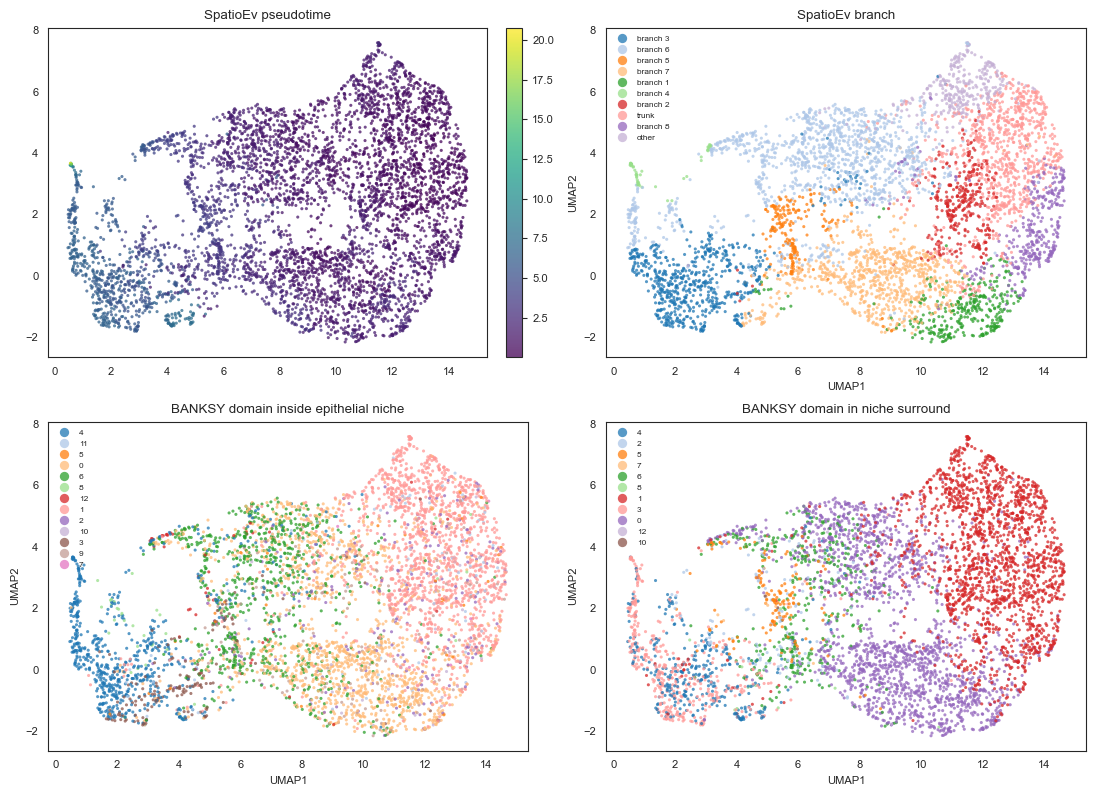

/Users/shihongwu/SpatioEv/notebooks/results/xenium_banksy_pseudotime/xenium_banksy_umap_overview.png


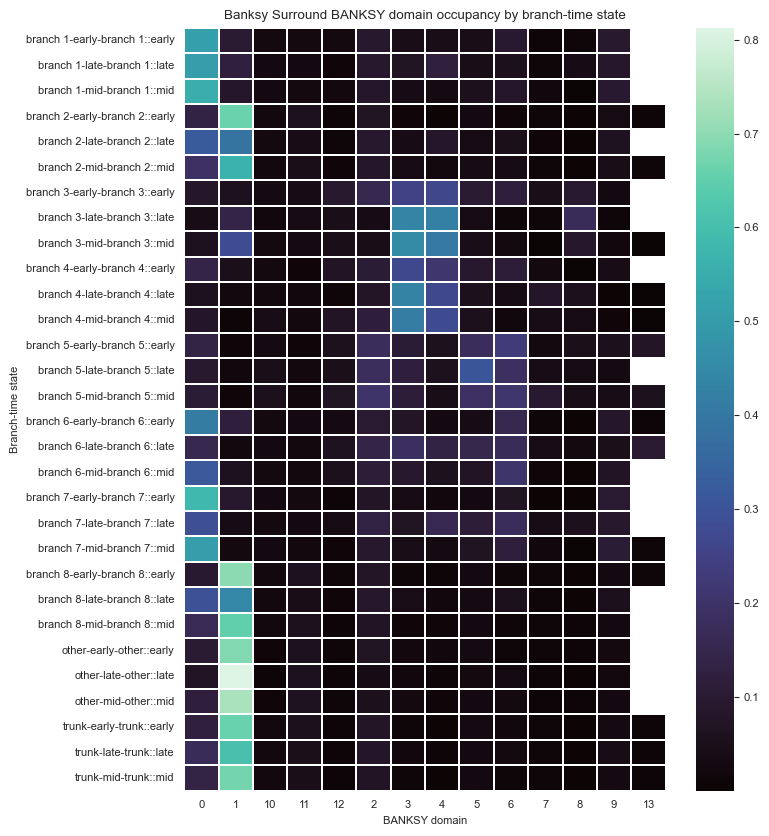

/Users/shihongwu/SpatioEv/notebooks/results/xenium_banksy_pseudotime/xenium_banksy_surround_banksy_branch_time_heatmap.png


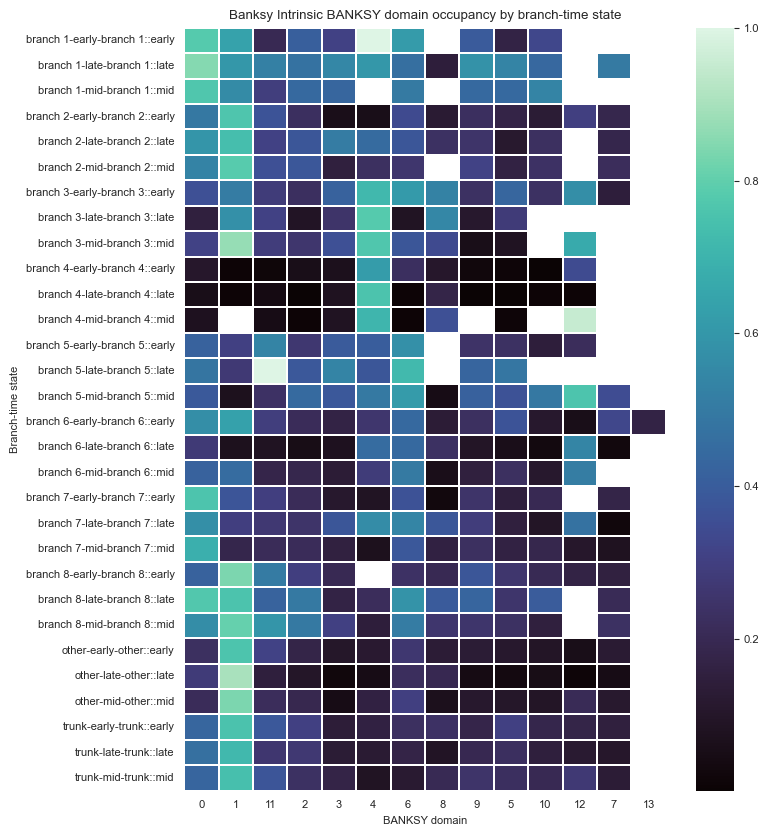

/Users/shihongwu/SpatioEv/notebooks/results/xenium_banksy_pseudotime/xenium_banksy_intrinsic_banksy_branch_time_heatmap.png


In [4]:
def plot_embedding(ax, df, color, title, cmap="viridis", palette=None, s=5, alpha=0.75):
    if color not in df.columns:
        ax.axis("off")
        ax.set_title(f"Missing: {color}")
        return
    if pd.api.types.is_numeric_dtype(df[color]):
        sc = ax.scatter(df["UMAP1"], df["UMAP2"], c=df[color], s=s, cmap=cmap, alpha=alpha, linewidths=0)
        plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
    else:
        sns.scatterplot(data=df, x="UMAP1", y="UMAP2", hue=color, palette=palette, s=s, alpha=alpha, linewidth=0, ax=ax)
        ax.legend(frameon=False, fontsize=6, loc="best", markerscale=3)
    ax.set_title(title)
    ax.grid(False)


def plot_banksy_overview(df):
    fig, axes = plt.subplots(2, 2, figsize=(11, 8))
    axes = axes.ravel()
    plot_embedding(axes[0], df, "xenium_pseudotime", "SpatioEv pseudotime")
    plot_embedding(axes[1], df, "major_branch", "SpatioEv branch", palette="tab20")
    plot_embedding(axes[2], df, "banksy_intrinsic__dominant_domain", "BANKSY domain inside epithelial niche", palette="tab20")
    plot_embedding(axes[3], df, "banksy_surround__dominant_domain", "BANKSY domain in niche surround", palette="tab20")
    plt.tight_layout()
    out = FIG_DIR / "xenium_banksy_umap_overview.png"
    plt.savefig(out, dpi=300, bbox_inches="tight")
    plt.show()
    print(out)


def plot_banksy_branch_heatmap(df, prefix="banksy_surround"):
    prop_cols = [c for c in df.columns if c.startswith(f"{prefix}__domain_") and c.endswith("__prop")]
    if len(prop_cols) == 0:
        print(f"No {prefix} domain proportion columns available.")
        return pd.DataFrame()
    summary = (
        df.dropna(subset=["branch_time_state"])
        .groupby(["major_branch", "branch_time_bin", "branch_time_state"], observed=True)[prop_cols]
        .mean()
    )
    renamed = summary.rename(columns=lambda c: c.replace(f"{prefix}__domain_", "").replace("__prop", ""))
    plt.figure(figsize=(max(8, 0.35 * renamed.shape[1]), max(4, 0.28 * renamed.shape[0])))
    sns.heatmap(renamed, cmap="mako", linewidths=0.2, linecolor="white")
    plt.title(f"{prefix.replace('_', ' ').title()} BANKSY domain occupancy by branch-time state")
    plt.xlabel("BANKSY domain")
    plt.ylabel("Branch-time state")
    plt.tight_layout()
    out = FIG_DIR / f"xenium_{prefix}_banksy_branch_time_heatmap.png"
    plt.savefig(out, dpi=300, bbox_inches="tight")
    plt.show()
    print(out)
    return renamed


banksy_integrated_path = BANKSY_DIR / "xenium_pseudotime_with_banksy.pkl"
if banksy_integrated_path.exists():
    banksy_pt_df = pd.read_pickle(banksy_integrated_path)
    display(banksy_pt_df.head())
    plot_banksy_overview(banksy_pt_df)
    banksy_surround_heatmap_df = plot_banksy_branch_heatmap(banksy_pt_df, prefix="banksy_surround")
    banksy_intrinsic_heatmap_df = plot_banksy_branch_heatmap(banksy_pt_df, prefix="banksy_intrinsic")
else:
    print("No integrated BANKSY table yet.")

## 4. Spatial scatter plots of BANKSY domains per sample

Plotting BANKSY domain column: banksy_harmony__scaled_gaussian__lambda_0p80__pc_20__res_0p50__relabeled


,sample_id,banksy_harmony__scaled_gaussian__lambda_0p80__pc_20__res_0p50__relabeled,n
0,normal_nondiseased_v1,1,75157
1,pdac_addon_v1,0,51224
2,pdac_io_v1,3,49994
3,pdac_io_v1,4,48842
4,pdac_pancreas_v1,0,37205
5,pdac_addon_v1,6,33817
6,pdac_addon_v1,5,31197
7,pdac_io_v1,2,30641
8,pdac_addon_v1,2,24422
9,pdac_pancreas_v1,2,21191


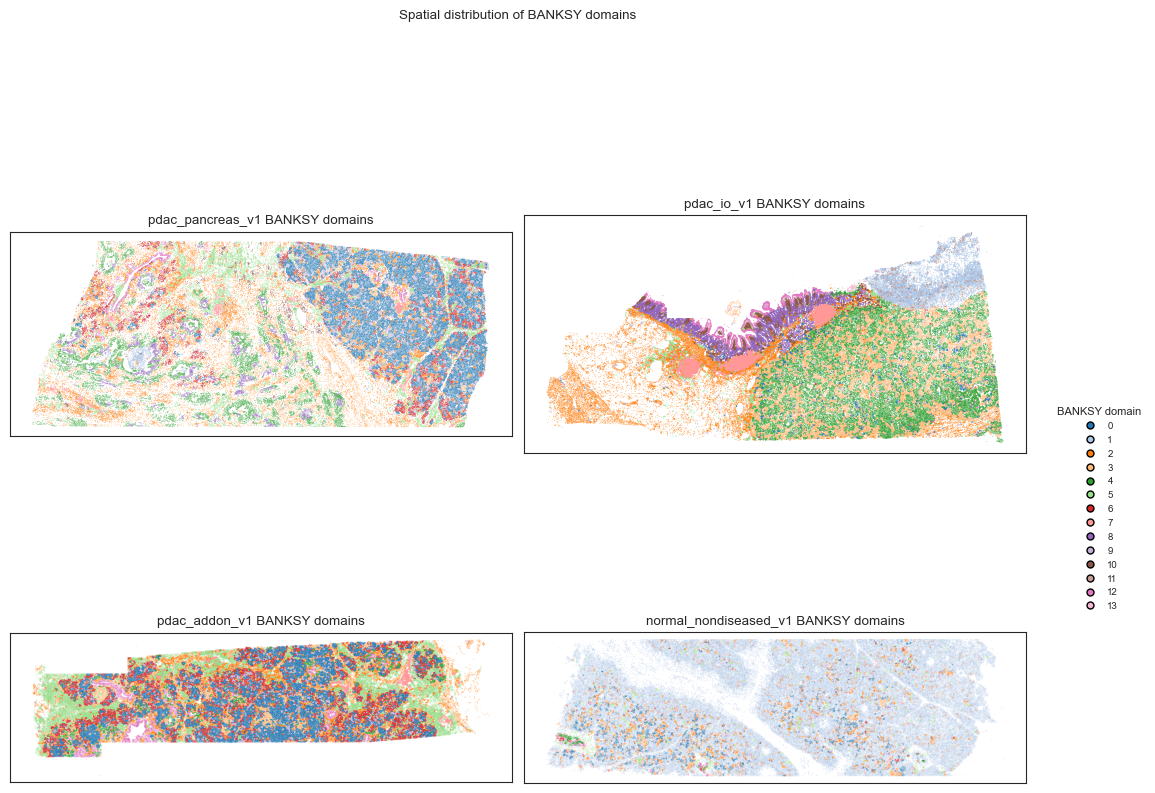

/Users/shihongwu/SpatioEv/notebooks/results/xenium_banksy_pseudotime/xenium_banksy_domains_spatial_by_sample.png


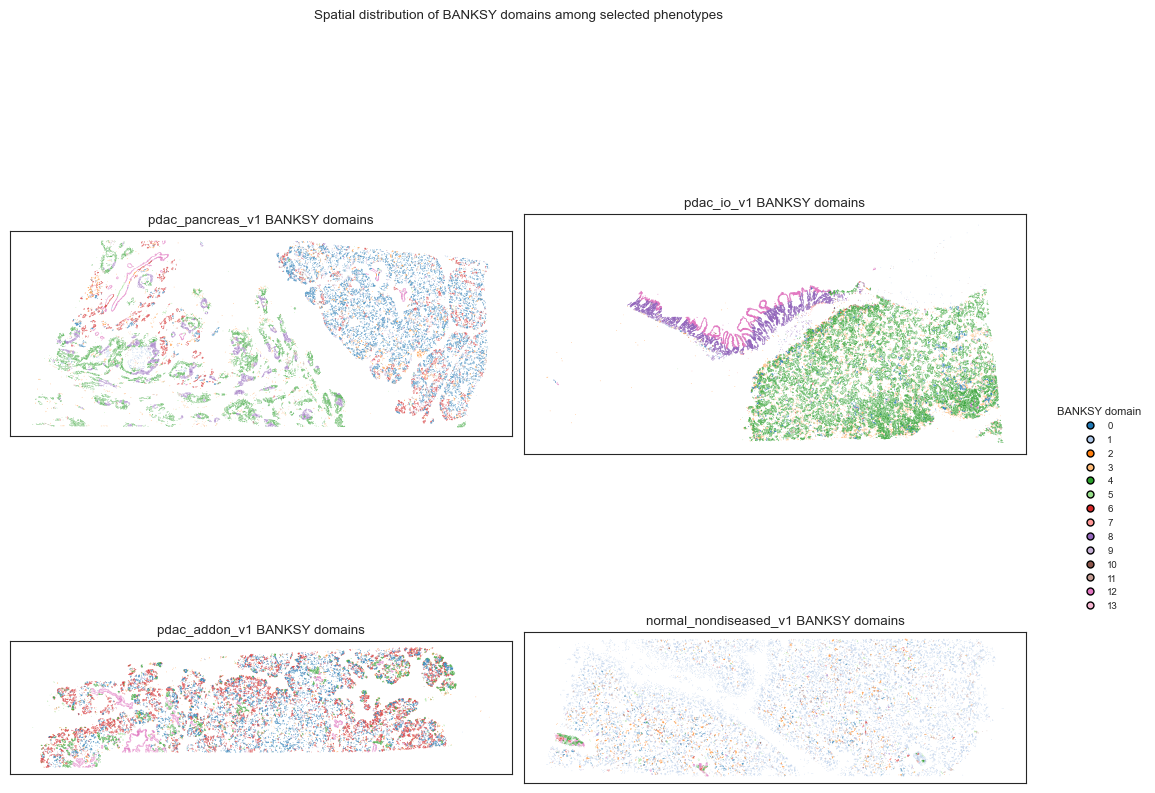

/Users/shihongwu/SpatioEv/notebooks/results/xenium_banksy_pseudotime/xenium_banksy_domains_spatial_epithelial_by_sample_filtered.png


In [7]:
from matplotlib.lines import Line2D


def infer_banksy_domain_col(df, preferred=None, use_relabeled=True):
    if preferred is not None and preferred in df.columns:
        base_col = preferred
    else:
        candidates = [
            c for c in df.columns
            if c.startswith(("banksy_harmony__", "banksy__")) and not c.endswith("__relabeled")
        ]
        if len(candidates) == 0:
            raise ValueError("No BANKSY domain columns found.")
        preferred_candidates = [
            c for c in candidates
            if "__lambda_0p80__" in c and "__res_0p50" in c
        ]
        base_col = preferred_candidates[0] if len(preferred_candidates) > 0 else candidates[0]
    relabeled_col = f"{base_col}__relabeled"
    if use_relabeled and relabeled_col in df.columns:
        return relabeled_col
    return base_col


def load_banksy_cell_domains(sample_ids=SAMPLE_IDS):
    frames = []
    for sample_id in sample_ids:
        path = BANKSY_DIR / sample_id / f"{sample_id}_banksy_cell_domains.csv.gz"
        if not path.exists():
            print(f"Missing BANKSY cell-domain file for {sample_id}: {path}")
            continue
        frames.append(pd.read_csv(path))
    if len(frames) == 0:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)


def make_domain_palette(values):
    values = pd.Series(values).dropna().astype(str).unique().tolist()
    try:
        values = sorted(values, key=lambda x: int(float(x)))
    except ValueError:
        values = sorted(values)
    colors = sns.color_palette("tab20", n_colors=max(len(values), 1))
    return dict(zip(values, colors))


def plot_banksy_domain_spatial_by_sample(
    cell_df,
    domain_col,
    sample_ids=SAMPLE_IDS,
    phenotype_filter=None,
    point_size=0.2,
    alpha=0.9,
    n_cols=2,
    save_name="xenium_banksy_domains_spatial_by_sample.png",
):
    plot_df = cell_df.copy()
    plot_df[domain_col] = plot_df[domain_col].astype(str)
    if phenotype_filter is not None:
        plot_df = plot_df.loc[plot_df["Tier_A"].isin(phenotype_filter)].copy()
        save_name = save_name.replace(".png", "_filtered.png")

    palette = make_domain_palette(plot_df[domain_col])
    n_rows = int(np.ceil(len(sample_ids) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.2 * n_cols, 4.8 * n_rows))
    axes = np.array(axes).reshape(-1)

    for ax, sample_id in zip(axes, sample_ids):
        tmp = plot_df.loc[plot_df["sample_id"] == sample_id].copy()
        if tmp.empty:
            ax.axis("off")
            ax.set_title(f"{sample_id}: no cells")
            continue
        colors = tmp[domain_col].map(palette)
        ax.scatter(
            tmp["banksy_x_original"],
            tmp["banksy_y_original"],
            c=colors,
            s=point_size,
            alpha=alpha,
            linewidths=0,
            rasterized=True,
        )
        ax.set_title(f"{sample_id} BANKSY domains")
        ax.set_aspect("equal", adjustable="box")
        ax.invert_yaxis()
        ax.set_xticks([])
        ax.set_yticks([])
        ax.grid(False)

    for ax in axes[len(sample_ids):]:
        ax.axis("off")

    handles = [
        Line2D([0], [0], marker="o", color="none", label=str(domain), markerfacecolor=color, markersize=5)
        for domain, color in palette.items()
    ]
    fig.legend(
        handles=handles,
        title="BANKSY domain",
        frameon=False,
        bbox_to_anchor=(1.01, 0.5),
        loc="center left",
        fontsize=7,
        title_fontsize=8,
    )
    fig.suptitle(
        f"Spatial distribution of BANKSY domains"
        + ("" if phenotype_filter is None else " among selected phenotypes"),
        y=1.02,
    )
    plt.tight_layout()
    out = FIG_DIR / save_name
    plt.savefig(out, dpi=300, bbox_inches="tight")
    plt.show()
    print(out)
    return out


banksy_cell_df = load_banksy_cell_domains()
if banksy_cell_df.empty:
    print("No BANKSY cell-domain tables found yet.")
else:
    banksy_spatial_domain_col = infer_banksy_domain_col(
        banksy_cell_df,
        preferred=BANKSY_PRIMARY_RUN_KEY,
        use_relabeled=True,
    )
    print("Plotting BANKSY domain column:", banksy_spatial_domain_col)
    display(banksy_cell_df[["sample_id", banksy_spatial_domain_col]].value_counts().rename("n").reset_index().head(20))

    plot_banksy_domain_spatial_by_sample(
        banksy_cell_df,
        domain_col=banksy_spatial_domain_col,
        point_size=0.2,
        save_name="xenium_banksy_domains_spatial_by_sample.png",
    )

    # Optional epithelial-only view, useful for comparing BANKSY domains with the epithelial trajectory backbone.
    plot_banksy_domain_spatial_by_sample(
        banksy_cell_df,
        domain_col=banksy_spatial_domain_col,
        phenotype_filter=["pancreatic ductal epithelium", "Mucosa gland"],
        point_size=0.18,
        save_name="xenium_banksy_domains_spatial_epithelial_by_sample.png",
    )

## Notes

BANKSY domains are spatially smoothed transcriptional domains. Here they are not used to define pseudotime; they are projected onto the morphology/topology-derived SpatioEv trajectory to ask which epithelial niche states and surrounding tissue states occupy each branch.